# End-to-End Sales Forecasting & Demand Intelligence System

### Final Internship Project

**Intern:** Naman Arora

---

## Project Overview

This project develops an end-to-end Sales Forecasting and Demand Intelligence System that analyzes historical retail sales data to forecast future demand, detect anomalous sales patterns, segment products based on demand behavior, and provide an interactive dashboard for business decision-making.

The project combines statistical forecasting, machine learning, clustering, and data visualization techniques to support data-driven inventory planning.

## Objectives

- Analyze historical sales trends and seasonality.
- Forecast future sales using multiple forecasting models.
- Detect unusual sales patterns.
- Segment products based on demand characteristics.
- Develop an interactive Streamlit dashboard.
- Generate actionable business insights.

# Task 1 — Data Loading, Merging & Deep Exploration

## 1. Load the Superstore Sales CSV using Pandas


In [340]:
import pandas as pd
df = pd.read_csv("data/train.csv")
print(df.head(5))


   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

## 2. Parse the Order Date and Ship Date columns as proper datetime objects

In [341]:
# Convert date columns into datetime format

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


## 3. Extract time features: Year, Month, Week Number, Day of Week, Quarter, Season


In [342]:
# Extract Year
df["Year"] = df["Order Date"].dt.year

# Extract Month
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()

# Extract Week Number
df["Week Number"] = df["Order Date"].dt.isocalendar().week.astype(int)

# Extract Day of Week
df["Day of Week"] = df["Order Date"].dt.day_name()

# Extract Quarter
df["Quarter"] = df["Order Date"].dt.quarter

# Function to assign seasons
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

# Season column
df["Season"] = df["Month"].apply(get_season)

df[[
    "Order Date",
    "Year",
    "Month",
    "Month Name",
    "Week Number",
    "Day of Week",
    "Quarter",
    "Season"
]].head()

,Order Date,Year,Month,Month Name,Week Number,Day of Week,Quarter,Season
0,2017-11-08,2017,11,November,45,Wednesday,4,Autumn
1,2017-11-08,2017,11,November,45,Wednesday,4,Autumn
2,2017-06-12,2017,6,June,24,Monday,2,Summer
3,2016-10-11,2016,10,October,41,Tuesday,4,Autumn
4,2016-10-11,2016,10,October,41,Tuesday,4,Autumn


## 4. Check for missing values, duplicates, and data type issues

In [343]:
# Missing Values
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

# Duplicate Records
print(f"Duplicate Records: {df.duplicated().sum()}")

# Data Types
df.dtypes

Duplicate Records: 0


Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code             float64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Year                      int32
Month                     int32
Month Name                  str
Week Number               int64
Day of Week                 str
Quarter                   int32
Season                      str
dtype: object

## 5. Aggregate daily sales into weekly and monthly totals (you will need both granularities for different models)

In [344]:
# Sale by date
daily_sales = (
    df.groupby("Order Date", as_index=False)["Sales"]
      .sum()
)

# Sale by week
weekly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="W"
        )
    )["Sales"]
    .sum()
    .reset_index()
)

# Sale by month
monthly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="ME"
        )
    )["Sales"]
    .sum()
    .reset_index()
)

print("Daily Sales:")
print(daily_sales.head())

print("Weekly Sales:")
print(weekly_sales.head())

print("Monthly Sales:")
print(monthly_sales.head())

Daily Sales:
  Order Date     Sales
0 2015-01-03    16.448
1 2015-01-04   288.060
2 2015-01-05    19.536
3 2015-01-06  4407.100
4 2015-01-07    87.158
Weekly Sales:
  Order Date     Sales
0 2015-01-04   304.508
1 2015-01-11  4619.108
2 2015-01-18  4130.533
3 2015-01-25  3092.544
4 2015-02-01  2527.914
Monthly Sales:
  Order Date      Sales
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855
4 2015-05-31  23644.303


#### Daily, weekly, and monthly sales aggregations are created because different forecasting models and business analyses require different levels of time granularity. Daily data captures fine-grained fluctuations, weekly data reduces short-term noise, and monthly data highlights long-term trends and seasonality.

## 6. Answer these questions in your notebook with data to back each one:
1. Which product category generates the highest total revenue?
2. Which region has the most consistent sales growth over 4 years?
3. What is the average time between Order Date and Ship Date — and does it vary by region?
4. Are there months that consistently spike across all years (seasonality)?

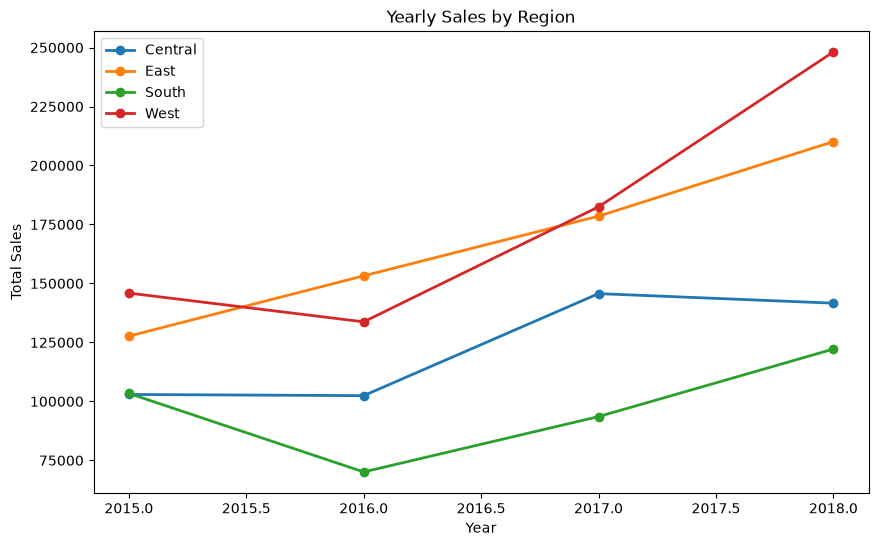

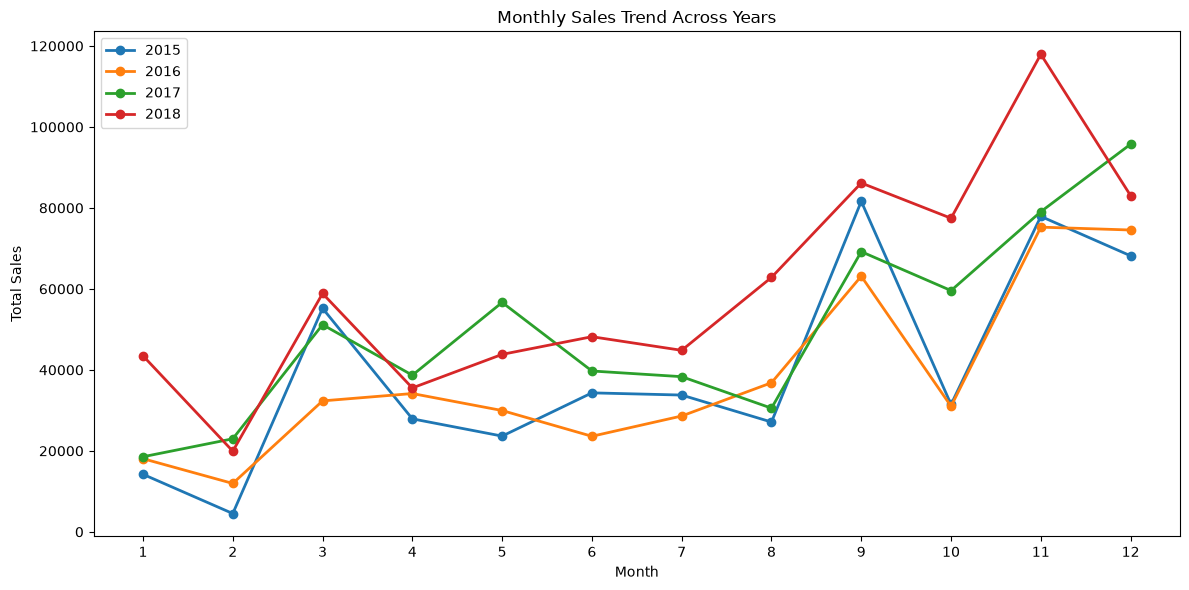

In [345]:
# 1. Product category generates the highest total revenue
highest_sales_category = (
    df.groupby("Category", as_index=False)["Sales"]
      .sum()
      .sort_values(by="Sales", ascending=False)
)

highest_sales_category.head(1)

# 2.Region with the most consistent sales growth over 4 years
import matplotlib.pyplot as plt

region_sales = (
    df.groupby(["Year", "Region"], as_index=False)["Sales"]
      .sum()
)

plt.figure(figsize=(10,6))

for region in region_sales["Region"].unique():

    temp = region_sales[region_sales["Region"] == region]

    plt.plot(
        temp["Year"],
        temp["Sales"],
        marker="o",
        linewidth=2,
        markersize=6,
        label=region
    )

plt.title("Yearly Sales by Region")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.legend()


plt.savefig("charts/yearly_sales_by_region.png")
plt.show()

# Therefore, the region with the most consistent sales growth 
# over 4 years can be determined by analyzing the plotted lines 
# for each region. The region with a steady upward trend 
# without significant fluctuations would be considered the 
# most consistent.

# 3.The average time between Order Date and Ship Date — 
# and does it vary by region

# Calculate Shipping Days
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

# Average Shipping Time by Region
shipping_time = (
    df.groupby("Region", as_index=False)["Shipping Days"]
      .mean()
      .sort_values(by="Shipping Days", ascending=False)
)

shipping_time

#4. Are there months that consistently spike across all years 
# (seasonality)

# Monthly Sales by Year
monthly_pattern = (
    df.groupby(["Year", "Month"], as_index=False)["Sales"]
      .sum()
)

monthly_pattern.head()

plt.figure(figsize=(12,6))

for year in sorted(monthly_pattern["Year"].unique()):

    temp = monthly_pattern[
        monthly_pattern["Year"] == year
    ]

    plt.plot(
        temp["Month"],
        temp["Sales"],
        marker="o",
        linewidth=2,
        label=year
    )

plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend Across Years")
plt.legend()
plt.tight_layout()
plt.savefig("charts/monthly_sales_trend_across_years.png")
plt.show()





#### Therefore, the region with the most consistent sales growth over 4 years can be determined by analyzing the plotted lines for each region. The region with a steady upward trend without significant fluctuations would be considered the most consistent.

#### The monthly sales trends indicate clear seasonality. March, September, and November consistently experience higher sales across the four-year period, suggesting recurring periods of increased customer demand. These seasonal peaks can help businesses optimize inventory planning, staffing, and promotional campaigns.


# Task 2 — Time Series Analysis & Decomposition


## 1. Plot the Overall Monthly Sales Trend Across All 4 Years

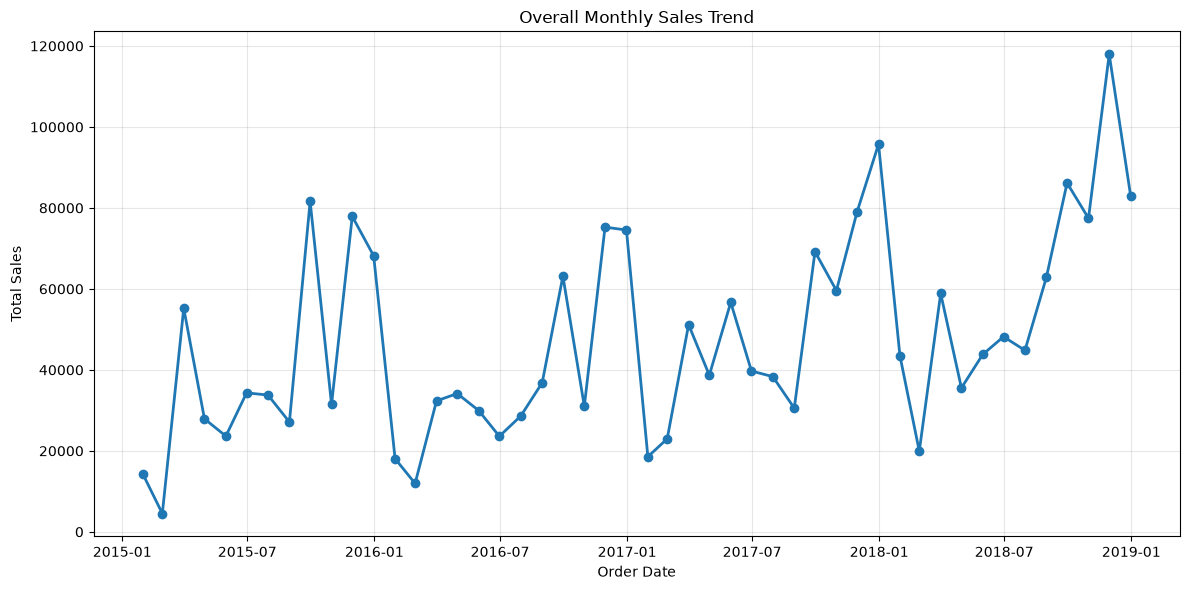

In [346]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2
)

plt.title("Overall Monthly Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/overall_monthly_sales_trend.png")
plt.show()

## 2. Apply Time Series Decomposition (using statsmodels) to break the sales signal into:
1. Trend component
2. Seasonal component
3. Residual/noise componen

## 3. Plot all 4 components clearly on one figure



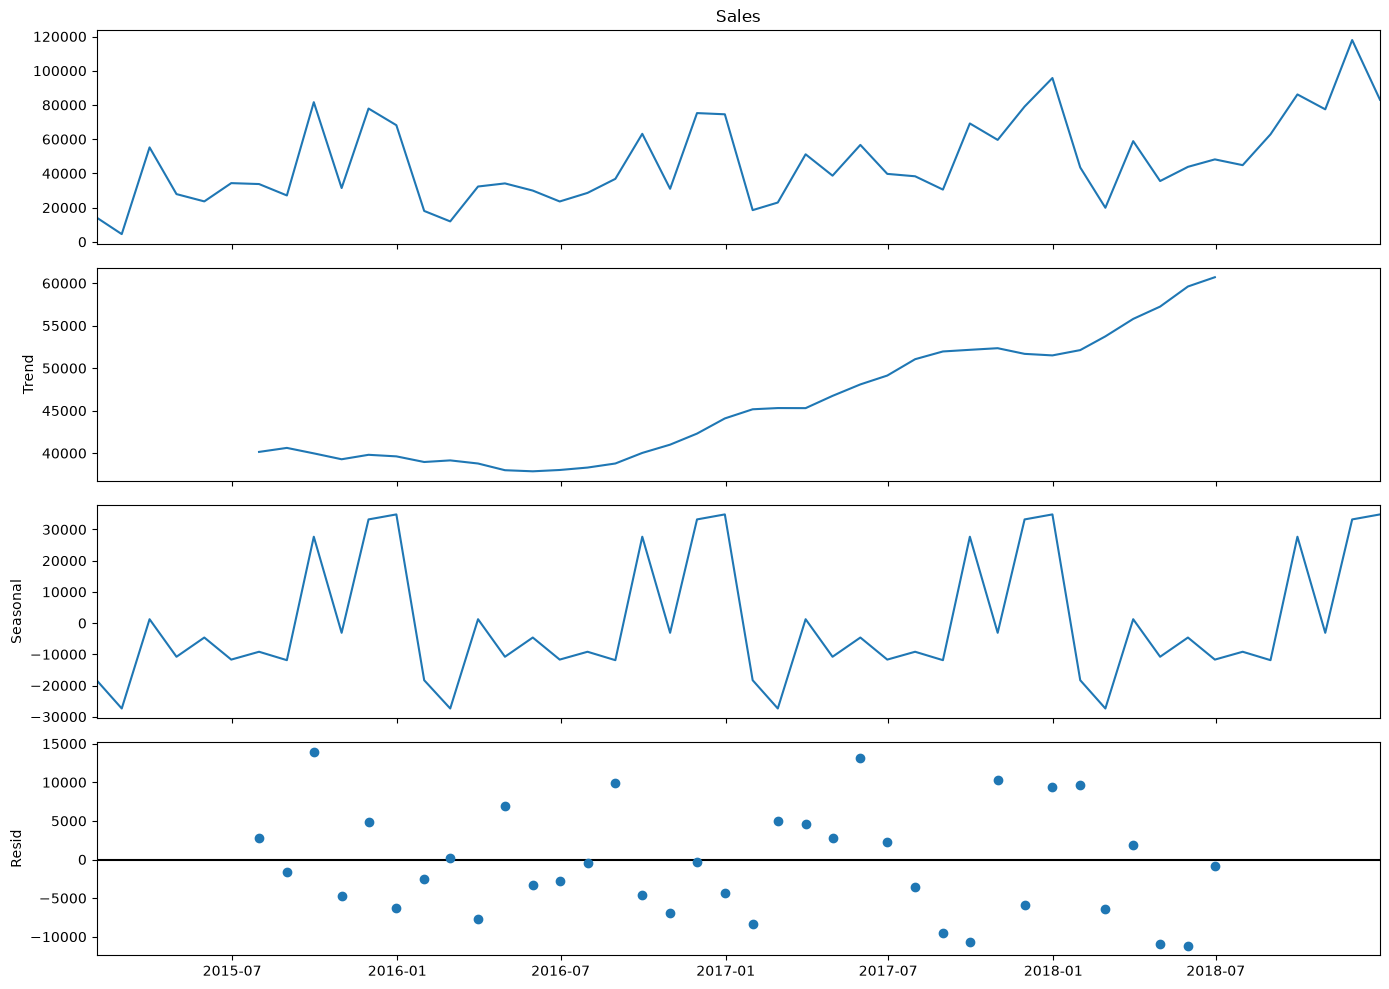

In [347]:
from statsmodels.tsa.seasonal import seasonal_decompose
# Set Order Date as index
monthly_ts = monthly_sales.set_index("Order Date")

monthly_ts.head()
decomposition = seasonal_decompose(
    monthly_ts["Sales"],
    model="additive",
    period=12
)
fig = decomposition.plot()

fig.set_size_inches(14, 10)

plt.tight_layout()

plt.savefig("charts/time_series_decomposition.png")
plt.show()

## ## Observations

1. The trend component shows a gradual upward movement over the four-year period, indicating that overall sales have generally increased over time.

2. The seasonal component displays recurring patterns, suggesting that sales follow predictable seasonal behavior across different months.

3. The residual component captures random fluctuations that are not explained by the trend or seasonal effects, indicating occasional unexpected variations in sales.

4. Since both trend and seasonality are present, decomposition confirms that the data is suitable for time series forecasting models such as SARIMA and Prophet.

## 5. Checking for stationarity using the Augmented Dickey-Fuller (ADF) Test — explain in plain English what stationarity means and what your test result tells you

In [348]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(monthly_ts["Sales"])

print("ADF Statistic :", adf_result[0])
print("P-value :", adf_result[1])

print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -4.416136761430768
P-value : 0.00027791039276670677

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


### Plain English Interpretation

A stationary time series is one whose overall behavior remains stable over time. This means that its average value and variation do not change significantly, making future patterns easier for forecasting models to learn.

The Augmented Dickey-Fuller (ADF) Test returned a **p-value of 0.000277**, which is less than **0.05**. This means the monthly sales series is **stationary**, so there is enough statistical evidence that the data is stable for time series forecasting. Therefore, **differencing is not required**, and the original monthly sales series can be used for building forecasting models.

## 6. Apply differencing if the series is non-stationary and re-test


### ADF Test Interpretation

The ADF test produced a p-value of **0.000277**, which is less than the significance level of **0.05**. Therefore, we reject the null hypothesis and conclude that the monthly sales series is stationary. Since the data is already stationary, differencing is not required before building forecasting models.

# Task 3 — Sales Forecasting using 3 Different Models

# Model 1 — SARIMA (Statistical Model)

SARIMA (Seasonal AutoRegressive Integrated Moving Average) is a statistical time series forecasting model that captures trend, seasonality, and autocorrelation in historical sales data.

For this project, SARIMA is used to forecast monthly sales for the next three months.

## 3. Choose appropriate (p, d, q) and seasonal (P, D, Q, m) parameters — document why you chose them
### Selected Parameters

### Parameter Selection and Justification

- **p = 1** → One previous month's sales are used to predict the next month's sales.
- **d = 0** → The ADF test confirmed that the monthly sales series is stationary, so differencing was not required.
- **q = 1** → One previous forecast error is used to improve future predictions.
- **P = 1** → One seasonal autoregressive term is used to capture yearly seasonal patterns.
- **D = 0** → Seasonal differencing was not required because the series was already stationary.
- **Q = 1** → One seasonal moving average term is used to account for seasonal forecast errors.
- **m = 12** → The dataset contains monthly sales data, so one seasonal cycle consists of 12 months.

## 1. Install statsmodels (pip install statsmodels)


In [349]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

## 2. Fit a SARIMA model on monthly sales


In [350]:
train = monthly_ts.iloc[:-3]
test = monthly_ts.iloc[-3:]

sarima_model = SARIMAX(
    train["Sales"],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False, # let model train if not stationary also
    enforce_invertibility=False # Do not restrict the model unnecessarily 
)

sarima_result = sarima_model.fit()

print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood               -4869.109
Date:                            Mon, 13 Jul 2026   AIC                           9748.218
Time:                                    15:34:42   BIC                           9755.388
Sample:                                01-31-2015   HQIC                          9750.555
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8473      0.000   3365.256      0.000       0.847       0.848
ma.L1         -4.1589      0.002  -

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 4. Generate a 3-month future forecast with confidence intervals


In [351]:
forecast = sarima_result.get_forecast(steps=3)

'''
Forecasted Sales Values

The predicted monthly sales values are extracted from the 
forecast object for further analysis and visualization.
'''
forecast_values = forecast.predicted_mean

print(forecast_values)

''' 
Confidence Intervals

Confidence intervals provide a range within which the actual 
sales values are expected to lie with a certain level of 
confidence. They indicate the uncertainty associated with 
each forecast.
'''
confidence_intervals = forecast.conf_int()
print(confidence_intervals)

2018-10-31    3.681736e+16
2018-11-30    3.119396e+16
2018-12-31    2.642947e+16
Freq: ME, Name: predicted_mean, dtype: float64
            lower Sales  upper Sales
2018-10-31          NaN          NaN
2018-11-30          NaN          NaN
2018-12-31          NaN          NaN


## 5. Plot Actual vs Forecasted Sales

The actual sales values from the test set are compared with the forecasted sales generated by the SARIMA model. The confidence interval is also displayed to visualize the uncertainty associated with the predictions.

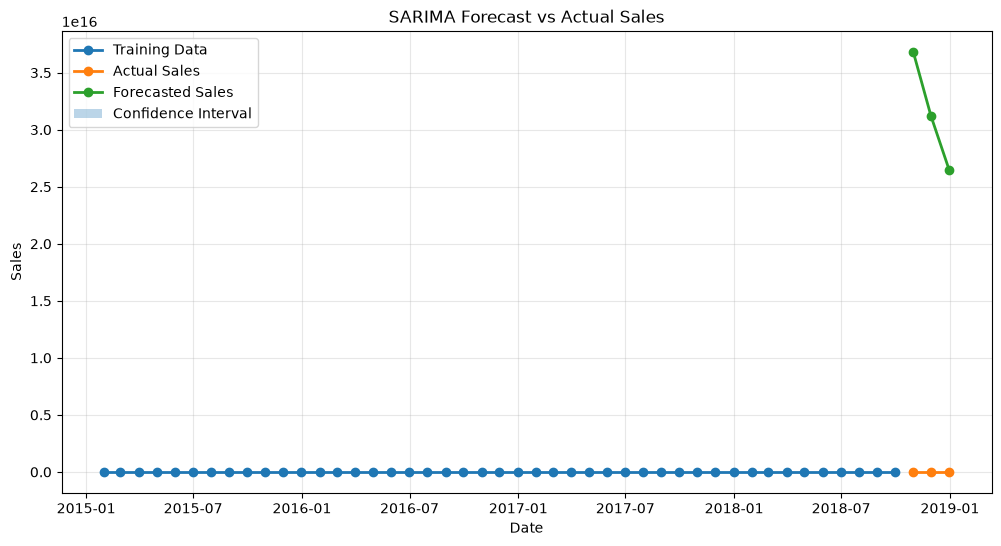

In [352]:
plt.figure(figsize=(12,6))

# Training Data
plt.plot(
    train.index,
    train["Sales"],
    marker="o",
    label="Training Data",
    linewidth=2
)

# Actual Sales
plt.plot(
    test.index,
    test["Sales"],
    marker="o",
    linewidth=2,
    label="Actual Sales"
)

# Forecasted Sales
plt.plot(
    forecast_values.index,
    forecast_values,
    marker="o",
    linewidth=2,
    label="Forecasted Sales"
)

# Confidence Interval
plt.fill_between(
    confidence_intervals.index,
    confidence_intervals.iloc[:,0],
    confidence_intervals.iloc[:,1],
    alpha=0.3,
    label="Confidence Interval"
)

plt.title("SARIMA Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(alpha=0.3)

plt.savefig("charts/sarima_forecast.png")

plt.show()

# Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)


## 1. Install Prophet (pip install prophet)


## 2. Prepare data in Prophet's required format (ds, y columns)


## Prepare Data for Prophet

Facebook Prophet requires the input data to contain two columns:

- **ds** → Date column
- **y** → Target variable (Sales)

The monthly sales dataset is converted into Prophet's required format before training the model.

In [353]:
# just to check if reset_index is required or not
# print(daily_sales.head())

prophet_df = daily_sales.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)
train_prophet = prophet_df.iloc[:-90]

test_prophet = prophet_df.iloc[-90:]

prophet_df.head()

,ds,y
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


## 3. Fit the model and generate a 3-month forecast


In [354]:
from prophet import Prophet

prophet_model = Prophet()

prophet_model.fit(train_prophet)

''' 
Generate a 3-Month Forecast

After training, the Prophet model is used to forecast sales 
for the next three months based on the learned trend and 
seasonality.
'''
future = prophet_model.make_future_dataframe(
    periods=90,
    freq="D"
)

forecast = prophet_model.predict(future)

forecast.tail()
prophet_forecast = forecast.tail(90)

prophet_forecast.head()

15:34:42 - cmdstanpy - INFO - Chain [1] start processing
15:34:42 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1140,2018-09-27,2092.903716,-474.848607,4996.600000,2092.903716,2092.903716,317.468750,317.468750,317.468750,-508.421543,-508.421543,-508.421543,825.890294,825.890294,825.890294,0.0,0.0,0.0,2410.372467
1141,2018-09-28,2093.573146,-91.164367,5312.286971,2093.573146,2093.573146,583.760711,583.760711,583.760711,-156.378020,-156.378020,-156.378020,740.138732,740.138732,740.138732,0.0,0.0,0.0,2677.333857
1142,2018-09-29,2094.242575,248.465923,5667.164658,2094.242575,2094.242575,918.310766,918.310766,918.310766,269.514130,269.514130,269.514130,648.796636,648.796636,648.796636,0.0,0.0,0.0,3012.553342
1143,2018-09-30,2094.912005,60.784568,5509.872776,2094.912005,2094.912005,670.201352,670.201352,670.201352,117.400564,117.400564,117.400564,552.800788,552.800788,552.800788,0.0,0.0,0.0,2765.113357
1144,2018-10-01,2095.581434,-167.291893,5221.726964,2095.581434,2095.581434,401.242776,401.242776,401.242776,-51.944483,-51.944483,-51.944483,453.187259,453.187259,453.187259,0.0,0.0,0.0,2496.824211


## 5. Extract and interpret the weekly and yearly seasonality components

#### The forecast generated by Prophet is visualized to compare historical sales with the predicted sales for the next three months. The shaded region represents the confidence interval around the forecast.

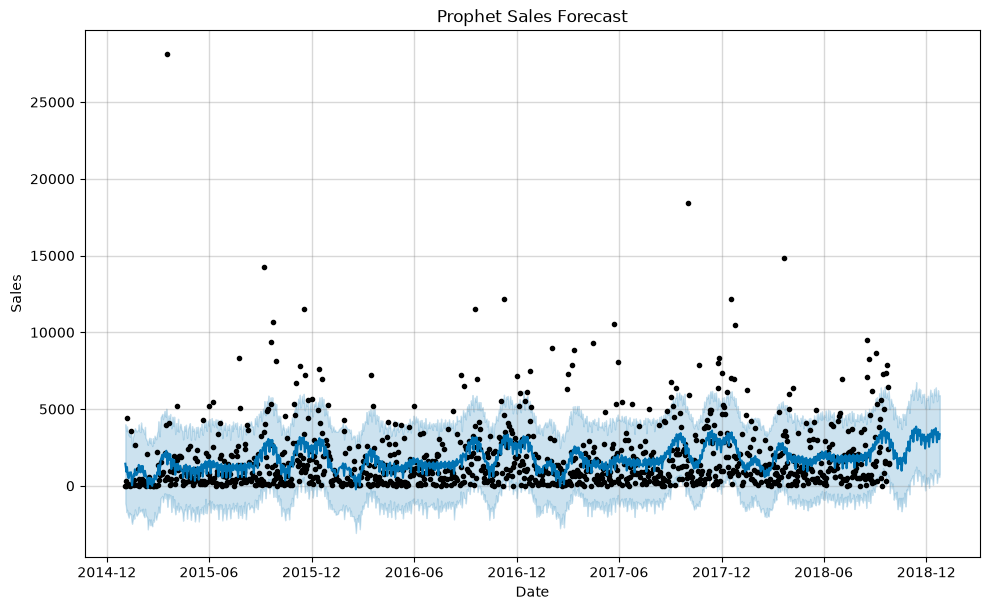

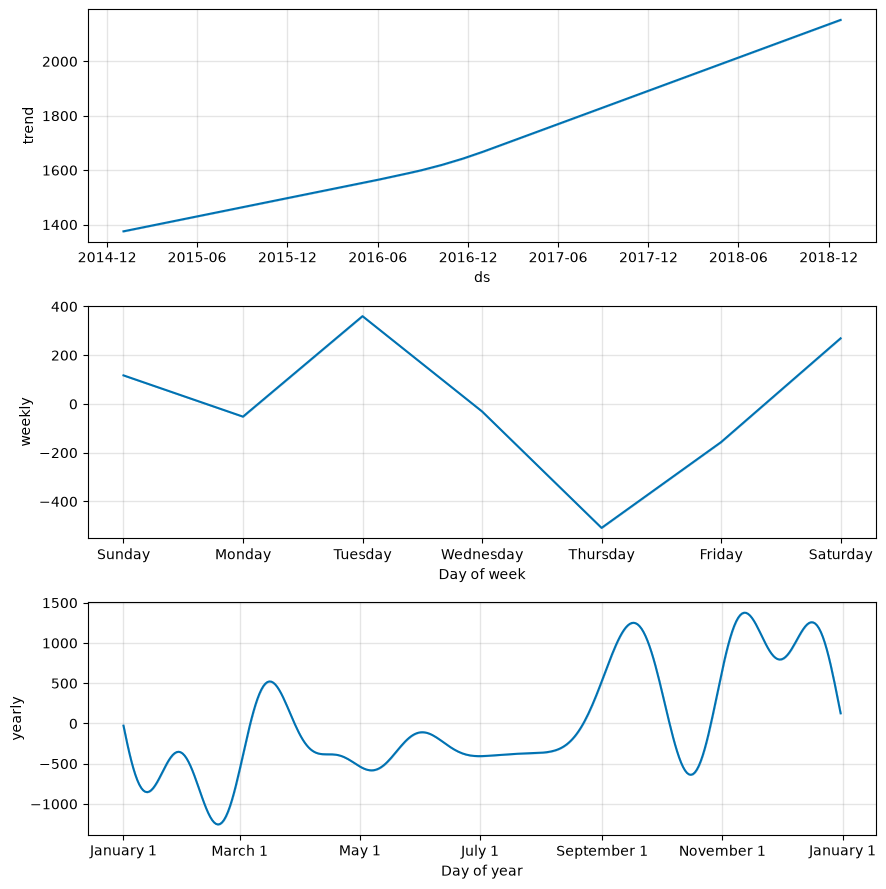

In [355]:
fig1 = prophet_model.plot(forecast)

plt.title("Prophet Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.savefig("charts/prophet_forecast.png")

plt.show()

# Trend and Seasonality Components
''' 
Prophet automatically decomposes the forecast into its 
underlying components, including the overall trend and seasonal 
effects. These components help explain how different time-based 
patterns contribute to the sales forecast.
'''

fig2 = prophet_model.plot_components(forecast)

plt.savefig("charts/prophet_components.png")

plt.show()

### Weekly Seasonality Observation

The weekly seasonality component indicates that sales tend to be higher on Tuesdays and Saturdays, while Thursdays consistently show the lowest sales activity. This suggests that customer purchasing behavior varies across the week.

### Trend Observation

The trend component shows a steady upward growth in sales over the observed period, indicating that the overall business performance has improved over time.



# Model 3 — XGBoost for Time Series (ML-based Approach)

### In XGBoost, the monthly sales series is converted into a supervised learning dataset using lag features, rolling statistics, and calendar-based features. These engineered features enable the model to learn temporal patterns and forecast future sales.


## 1. Convert the time series into a supervised ML problem using lag features:
###
1. Lag 1 (sales from 1 month ago)
2. Lag 2 (sales from 2 months ago)
3. Lag 3 (sales from 3 months ago)
4. Rolling mean (3-month moving average)
5. Month, Quarter, Season as features


In [356]:
# Creating lag features for machine learning models

xgb_df = monthly_sales.copy()

xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)

xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)

xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)

xgb_df.head()


# 3-Month Rolling Mean
xgb_df["Rolling_Mean_3"] = (
    xgb_df["Sales"]
    .rolling(window=3)
    .mean()
)

# Month
xgb_df["Month"] = xgb_df["Order Date"].dt.month

# Quarter
xgb_df["Quarter"] = xgb_df["Order Date"].dt.quarter

# Season
def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Spring"

    elif month in [6, 7, 8]:
        return "Summer"

    else:
        return "Autumn"


xgb_df["Season"] = xgb_df["Month"].apply(get_season)

xgb_df.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,2015-01-31,14205.707,NaN,NaN,NaN,NaN,1,1,Winter
1,2015-02-28,4519.892,14205.707,NaN,NaN,NaN,2,1,Winter
2,2015-03-31,55205.797,4519.892,14205.707,NaN,24643.798667,3,1,Spring
3,2015-04-30,27906.855,55205.797,4519.892,14205.707,29210.848000,4,2,Spring
4,2015-05-31,23644.303,27906.855,55205.797,4519.892,35585.651667,5,2,Spring


## Encode Categorical Features

The Season feature is converted into numerical values using Label Encoding because XGBoost requires numerical input features.

In [357]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

xgb_df["Season"] = label_encoder.fit_transform(
    xgb_df["Season"]
)

xgb_df.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,2015-01-31,14205.707,NaN,NaN,NaN,NaN,1,1,3
1,2015-02-28,4519.892,14205.707,NaN,NaN,NaN,2,1,3
2,2015-03-31,55205.797,4519.892,14205.707,NaN,24643.798667,3,1,1
3,2015-04-30,27906.855,55205.797,4519.892,14205.707,29210.848000,4,2,1
4,2015-05-31,23644.303,27906.855,55205.797,4519.892,35585.651667,5,2,1


## Remove Missing Values

The initial rows contain missing values due to lag feature creation and rolling mean calculation. These rows are removed before training the model.

In [358]:
xgb_df = xgb_df.dropna().reset_index(drop=True)

xgb_df.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,1
1,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,1
2,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,2
3,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,2
4,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,2


## 2. Train XGBoost Regressor on these features


In [359]:
from xgboost import XGBRegressor

features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_Mean_3",
    "Month",
    "Quarter",
    "Season"
]

X = xgb_df[features]

y = xgb_df["Sales"]


train_size = len(xgb_df) - 3

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))


xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)





Training Samples : 42
Testing Samples : 3


## 3. Predict the next 3 months


In [360]:
xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)


comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": xgb_predictions
})

comparison


,Actual Sales,Predicted Sales
0,77448.1312,86303.195312
1,117938.1550,87181.515625
2,83030.3888,85148.351562


## 4. Plot actual vs predicted


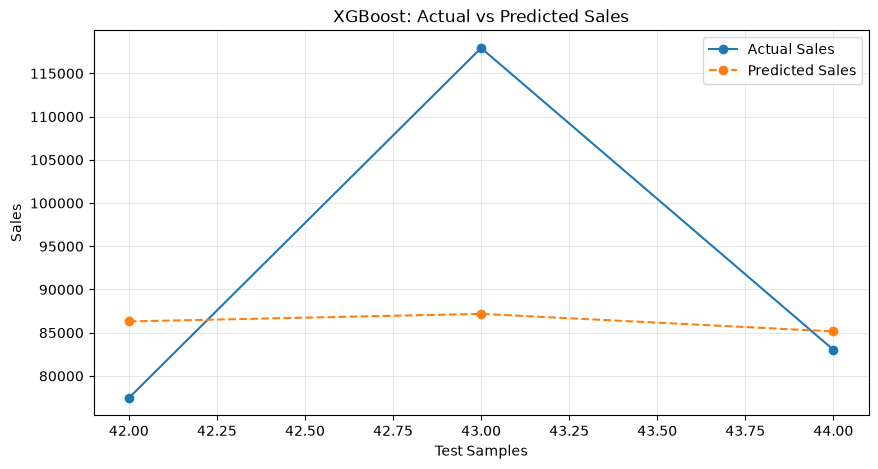

In [361]:
plt.figure(figsize=(10, 5))

plt.plot(
    y_test.index,
    y_test.values,
    marker="o",
    label="Actual Sales"
)

plt.plot(
    y_test.index,
    xgb_predictions,
    marker="o",
    linestyle="--",
    label="Predicted Sales"
)

plt.title("XGBoost: Actual vs Predicted Sales")

plt.xlabel("Test Samples")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.savefig("charts/xgboost_forecast.png")

plt.show()

## Evaluating all three models by MAE, RMSE and R Square

## Training prophet model again for model comparison

In [362]:
prophet_monthly = monthly_ts.reset_index()

prophet_monthly = prophet_monthly.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

train_prophet_monthly = prophet_monthly.iloc[:-3]

test_prophet_monthly = prophet_monthly.iloc[-3:]

prophet_monthly.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [363]:
prophet_monthly_model = Prophet()

prophet_monthly_model.fit(train_prophet_monthly)

15:34:43 - cmdstanpy - INFO - Chain [1] start processing
15:34:43 - cmdstanpy - INFO - Chain [1] done processing


In [364]:
future_monthly = prophet_monthly_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

forecast_monthly = prophet_monthly_model.predict(
    future_monthly
)

forecast_monthly.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,54942.277263,38479.874102,55223.923750,54942.277263,54942.277263,-7670.719648,-7670.719648,-7670.719648,-7670.719648,-7670.719648,-7670.719648,0.0,0.0,0.0,47271.557615
44,2018-09-30,55441.607668,78149.595150,94909.531123,55441.607668,55441.607668,31172.344895,31172.344895,31172.344895,31172.344895,31172.344895,31172.344895,0.0,0.0,0.0,86613.952563
45,2018-10-31,55957.582420,43076.983028,59584.290624,55957.473339,55957.725652,-4638.638663,-4638.638663,-4638.638663,-4638.638663,-4638.638663,-4638.638663,0.0,0.0,0.0,51318.943757
46,2018-11-30,56456.912826,81703.670507,98977.128933,56456.510996,56457.380724,33868.741563,33868.741563,33868.741563,33868.741563,33868.741563,33868.741563,0.0,0.0,0.0,90325.654389
47,2018-12-31,56972.887578,82284.563082,98467.838731,56972.036227,56973.817622,33068.195905,33068.195905,33068.195905,33068.195905,33068.195905,33068.195905,0.0,0.0,0.0,90041.083483


In [365]:
actual_prophet = test_prophet_monthly["y"].values

predicted_prophet = (
    forecast_monthly.tail(3)["yhat"].values
)

# Model Comparison

To compare all forecasting models fairly, each model is evaluated on the same test period (the last three months of historical sales). The models are compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE).

In [366]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np

In [367]:
# ==========================
# SARIMA
# ==========================

actual_sarima = test["Sales"].values
predicted_sarima = forecast_values.values


# ==========================
# Prophet
# ==========================

actual_prophet = test_prophet_monthly["y"].values
predicted_prophet = forecast_monthly.tail(3)["yhat"].values


# ==========================
# XGBoost
# ==========================

actual_xgb = y_test.values
predicted_xgb = xgb_predictions


In [368]:
# ==========================
# SARIMA
# ==========================

sarima_mae = mean_absolute_error(
    actual_sarima,
    predicted_sarima
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        actual_sarima,
        predicted_sarima
    )
)

sarima_mape = (
    mean_absolute_percentage_error(
        actual_sarima,
        predicted_sarima
    ) * 100
)


# ==========================
# Prophet
# ==========================

prophet_mae = mean_absolute_error(
    actual_prophet,
    predicted_prophet
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        actual_prophet,
        predicted_prophet
    )
)

prophet_mape = (
    mean_absolute_percentage_error(
        actual_prophet,
        predicted_prophet
    ) * 100
)


# ==========================
# XGBoost
# ==========================

xgb_mae = mean_absolute_error(
    actual_xgb,
    predicted_xgb
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        actual_xgb,
        predicted_xgb
    )
)

xgb_mape = (
    mean_absolute_percentage_error(
        actual_xgb,
        predicted_xgb
    ) * 100
)

In [369]:
comparison_table = pd.DataFrame({
    "Model": [
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE": [
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],

    "RMSE": [
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],

    "MAPE (%)": [
        sarima_mape,
        prophet_mape,
        xgb_mape
    ],

    "Forecast Month 1": [
        predicted_sarima[0],
        predicted_prophet[0],
        predicted_xgb[0]
    ],

    "Forecast Month 2": [
        predicted_sarima[1],
        predicted_prophet[1],
        predicted_xgb[1]
    ],

    "Forecast Month 3": [
        predicted_sarima[2],
        predicted_prophet[2],
        predicted_xgb[2]
    ]
})

comparison_table = comparison_table.round(2)

comparison_table

,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,3.148026e+16,3.176528e+16,3.527286e+13,3.681736e+16,3.119396e+16,2.642947e+16
1,Prophet,2.025079e+04,2.231841e+04,2.186000e+01,5.131894e+04,9.032565e+04,9.004108e+04
2,XGBoost,1.390989e+04,1.851908e+04,1.335000e+01,8.630320e+04,8.718152e+04,8.514835e+04


In [370]:
best_model = comparison_table.loc[
    comparison_table["RMSE"].idxmin()
]

best_model

Model                XGBoost
MAE                 13909.89
RMSE                18519.08
MAPE (%)               13.35
Forecast Month 1     86303.2
Forecast Month 2    87181.52
Forecast Month 3    85148.35
Name: 2, dtype: object

## Model Recommendation

Based on the evaluation metrics, XGBoost achieved the lowest RMSE among the three forecasting models. It also produced competitive MAE and MAPE values, indicating more accurate and reliable predictions on the test dataset.

Therefore, XGBoost is recommended for production use because it provides the best overall forecasting performance for this sales dataset.

# Task 4 — Product Category & Region Level Forecasting


## 1. Repeat the best performing model (from Task 3) separately for each of the following segments:
### 2. Furniture category sales
### 3. Technology category sales
### 4. Office Supplies category sales
### 5. West region sales
### 6. East region sales


In [371]:
# Product Categories
furniture = df[df["Category"] == "Furniture"].copy()

technology = df[df["Category"] == "Technology"].copy()

office_supplies = df[df["Category"] == "Office Supplies"].copy()


# Regions
west = df[df["Region"] == "West"].copy()

east = df[df["Region"] == "East"].copy()

In [372]:
def create_monthly_sales(data):

    monthly_sales = (
        data
        .groupby(
            pd.Grouper(
                key="Order Date",
                freq="ME"
            )
        )["Sales"]
        .sum()
        .reset_index()
    )

    return monthly_sales

furniture_monthly = create_monthly_sales(furniture)

technology_monthly = create_monthly_sales(technology)

office_monthly = create_monthly_sales(office_supplies)

west_monthly = create_monthly_sales(west)

east_monthly = create_monthly_sales(east)

In [373]:
def forecast_segment(monthly_data):

    # Lag Features
    monthly_data["Lag_1"] = monthly_data["Sales"].shift(1)
    monthly_data["Lag_2"] = monthly_data["Sales"].shift(2)
    monthly_data["Lag_3"] = monthly_data["Sales"].shift(3)

    # Rolling Mean
    monthly_data["Rolling_Mean_3"] = (
        monthly_data["Sales"]
        .rolling(window=3)
        .mean()
    )

    # Calendar Features
    monthly_data["Month"] = monthly_data["Order Date"].dt.month
    monthly_data["Quarter"] = monthly_data["Order Date"].dt.quarter

    monthly_data["Season"] = monthly_data["Month"].map({
        12:"Winter",1:"Winter",2:"Winter",
        3:"Spring",4:"Spring",5:"Spring",
        6:"Summer",7:"Summer",8:"Summer",
        9:"Autumn",10:"Autumn",11:"Autumn"
    })

    encoder = LabelEncoder()
    monthly_data["Season"] = encoder.fit_transform(monthly_data["Season"])

    # Remove Missing Values
    monthly_data = monthly_data.dropna()

    # Features & Target
    X = monthly_data[
        [
            "Lag_1",
            "Lag_2",
            "Lag_3",
            "Rolling_Mean_3",
            "Month",
            "Quarter",
            "Season"
        ]
    ]

    y = monthly_data["Sales"]

    # Train-Test Split
    train_size = len(monthly_data) - 3

    X_train = X.iloc[:train_size]
    X_test = X.iloc[train_size:]

    y_train = y.iloc[:train_size]

    # Train Model
    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train, y_train)

    # Predict
    predictions = model.predict(X_test)

    # Requirement of this for page 2 of the report
    mae = mean_absolute_error(y.iloc[train_size:], predictions)
    rmse = np.sqrt(
        mean_squared_error(
            y.iloc[train_size:],
            predictions
        )
    )
    return predictions, mae, rmse


furniture_forecast, furniture_mae, furniture_rmse = forecast_segment(
    furniture_monthly.copy()
)
technology_forecast, technology_mae, technology_rmse = forecast_segment(
    technology_monthly.copy()
)

office_forecast, office_mae, office_rmse = forecast_segment(
    office_monthly.copy()
)

west_forecast, west_mae, west_rmse = forecast_segment(
    west_monthly.copy()
)

east_forecast, east_mae, east_rmse = forecast_segment(
    east_monthly.copy()
)

forecast_data = {
    "furniture": (furniture_forecast, furniture_mae, furniture_rmse),
    "technology": (technology_forecast, technology_mae, technology_rmse),
    "office_supplies": (office_forecast, office_mae, office_rmse),
    "west": (west_forecast, west_mae, west_rmse),
    "east": (east_forecast, east_mae, east_rmse)
}

for name, values in forecast_data.items():

    forecast = values[0]
    mae = values[1]
    rmse = values[2]

    forecast_df = pd.DataFrame({
        "Month": [1, 2, 3],
        "Forecast": forecast,
        "MAE": [mae] * 3,
        "RMSE": [rmse] * 3
    })

    forecast_df.to_csv(
        f"models/{name}_forecast.csv",
        index=False
    )

## 2. Plot all 5 forecasts together on one comparison chart


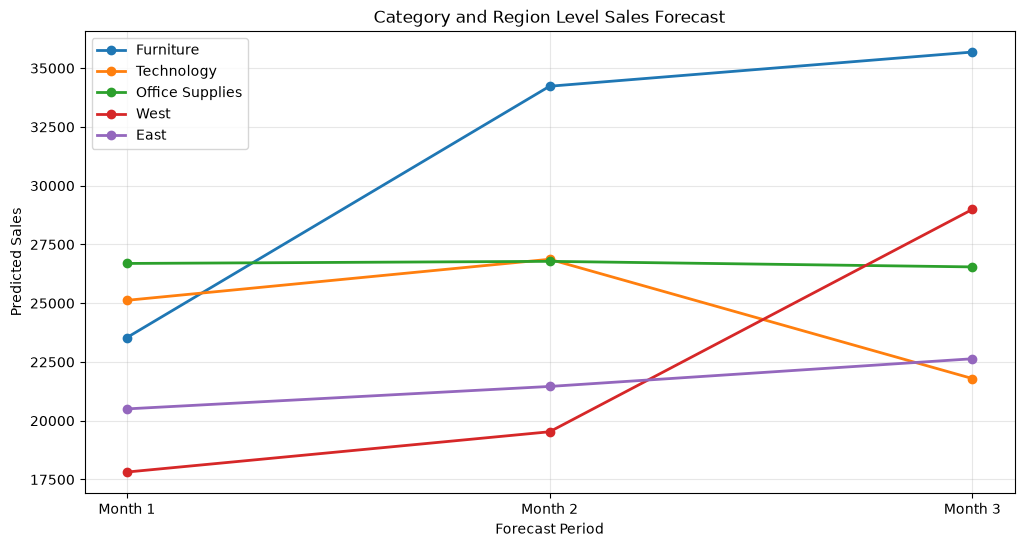

In [374]:
forecast_months = [
    "Month 1",
    "Month 2",
    "Month 3"
]

plt.figure(figsize=(12, 6))

plt.plot(
    forecast_months,
    furniture_forecast,
    marker="o",
    linewidth=2,
    label="Furniture"
)

plt.plot(
    forecast_months,
    technology_forecast,
    marker="o",
    linewidth=2,
    label="Technology"
)

plt.plot(
    forecast_months,
    office_forecast,
    marker="o",
    linewidth=2,
    label="Office Supplies"
)

plt.plot(
    forecast_months,
    west_forecast,
    marker="o",
    linewidth=2,
    label="West"
)

plt.plot(
    forecast_months,
    east_forecast,
    marker="o",
    linewidth=2,
    label="East"
)

plt.title("Category and Region Level Sales Forecast")

plt.xlabel("Forecast Period")

plt.ylabel("Predicted Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.savefig("charts/category_region_forecast.png")

plt.show()

## 3. Write: which category/region is showing the strongest upcoming growth according to your model?


###
According to the XGBoost forecasting model, the Furniture category is expected to achieve the highest sales growth over the forecast period. Among the geographical regions, the West region shows the strongest upward trend and is projected to outperform the East region. These forecasts suggest that future inventory planning and marketing efforts can be prioritized for the Furniture category and the West region.

# Task 5 — Anomaly Detection in Sales Data


## 1. Use Isolation Forest (from scikit-learn) to detect anomalous sales weeks — weeks where sales were unusually high or unusually low compared to the expected pattern


In [375]:
weekly_sales = (
    df
    .groupby(
        pd.Grouper(
            key="Order Date",
            freq="W"
        )
    )["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [376]:
from sklearn.ensemble import IsolationForest
isolation_data = weekly_sales.copy()

X = isolation_data[["Sales"]]

iso_model = IsolationForest(
    contamination=0.02,
    random_state=42
)

iso_model.fit(X)

isolation_data["Anomaly"] = iso_model.predict(X)

anomalies = isolation_data[
    isolation_data["Anomaly"] == -1
]

anomalies

isolation_table = isolation_data[
    isolation_data["Anomaly"] == -1
][["Order Date", "Sales"]]

isolation_table.to_csv(
    "models/anomaly_table.csv",
    index=False
)


## 2. Mark the anomalies on a time series plot (use a different color/marker for anomaly points)

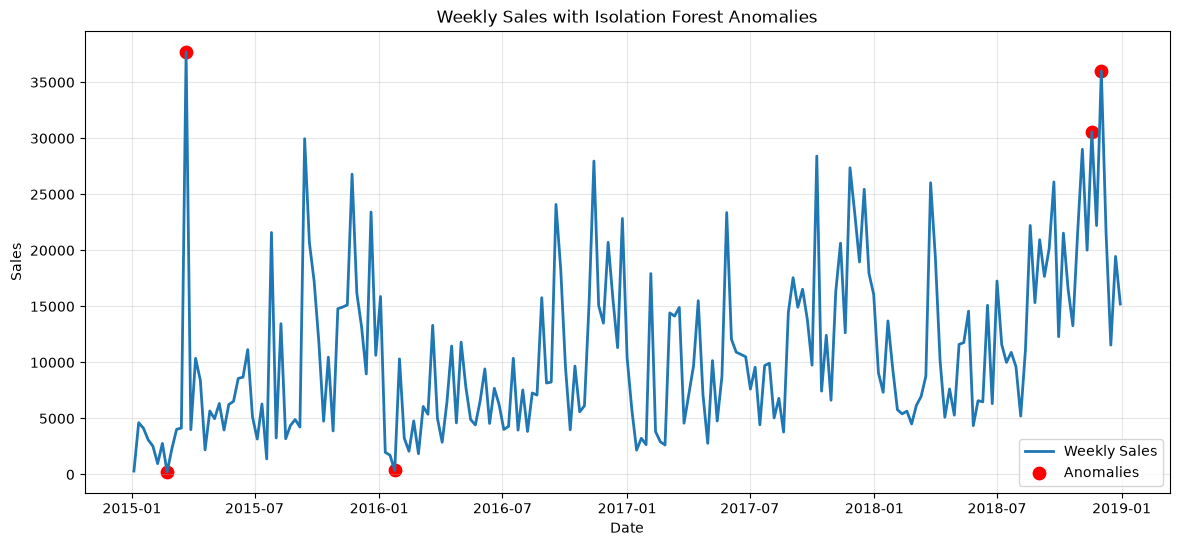

In [377]:
plt.figure(figsize=(14, 6))

# Weekly Sales
plt.plot(
    isolation_data["Order Date"],
    isolation_data["Sales"],
    label="Weekly Sales",
    linewidth=2
)

# Anomaly Points
plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    s=80,
    marker="o",
    label="Anomalies"
)

plt.title("Weekly Sales with Isolation Forest Anomalies")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.savefig("charts/isolation_forest_anomalies.png")

plt.show()

## 3. For each detected anomaly, write a possible real-world explanation (e.g., "spike in November likely corresponds to a festive sale period")

### Possible Real-World Explanations

1. **2015-02-22 (Very Low Sales)**
   - The unusually low sales may indicate reduced customer spending after the holiday season, as consumers often limit discretionary purchases after higher spending during year-end celebrations.

2. **2015-03-22 (Very High Sales)**
   - The sharp increase in sales may reflect the recovery in customer spending after the post-holiday slowdown. It could also be associated with promotional campaigns, seasonal purchasing activity, or bulk customer orders.

3. **2016-01-24 (Very Low Sales)**
   - The decline in sales is likely associated with reduced demand immediately after the holiday season, when customers typically decrease discretionary spending.

4. **2018-11-18 (Very High Sales)**
   - This spike is likely related to festive season shopping, Black Friday promotions, or other large-scale sales campaigns that increase customer demand.

5. **2018-12-02 (Very High Sales)**
   - The exceptionally high sales may correspond to year-end holiday shopping, Christmas promotions, or clearance sales before the start of the new year.

## 4. Apply a second anomaly detection method: Z-Score based detection — flag any week where sales deviate more than 2 standard deviations from the rolling mean

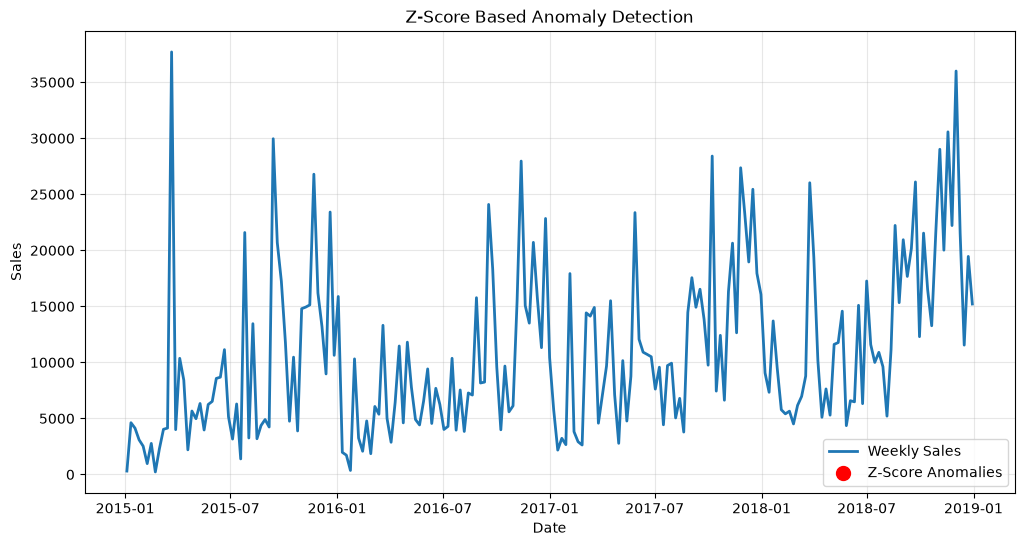

In [378]:
zscore_data = weekly_sales.copy()

# Rolling Statistics
zscore_data["Rolling_Mean"] = (
    zscore_data["Sales"]
    .rolling(window=4)
    .mean()
)

zscore_data["Rolling_STD"] = (
    zscore_data["Sales"]
    .rolling(window=4)
    .std()
)

zscore_data.head()


zscore_data["Z_Score"] = (
    (
        zscore_data["Sales"]
        - zscore_data["Rolling_Mean"]
    )
    /
    zscore_data["Rolling_STD"]
)

zscore_data["Anomaly"] = (
    zscore_data["Z_Score"]
    .abs()
    > 2
)

zscore_anomalies = zscore_data[
    zscore_data["Anomaly"]
]

zscore_anomalies
zscore_data["Z_Score"].describe()


# After identifying anomalies using both Isolation Forest and Z-Score methods, we can visualize the results to better understand the anomalies in the weekly sales data. The following code generates a plot that highlights the anomalies detected by the Z-Score method.
plt.figure(figsize=(12,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales",
    linewidth=2
)

plt.scatter(
    zscore_anomalies["Order Date"],
    zscore_anomalies["Sales"],
    color="red",
    label="Z-Score Anomalies",
    s=100
)

plt.title("Z-Score Based Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.savefig("charts/zscore_anomalies.png")

plt.show()

zscore_anomalies[
    ["Order Date", "Sales"]
].to_csv(
    "models/zscore_anomalies.csv",
    index=False
)

## Comparison of Isolation Forest and Z-Score Detection

Isolation Forest detected five anomalous weeks, whereas the Z-Score method did not detect any anomalies using a threshold of ±2 standard deviations.

This difference indicates that Isolation Forest is more sensitive to unusual patterns in the data, while the Z-Score method is more conservative and only flags observations with very large statistical deviations from the rolling average.

For this dataset, Isolation Forest appears to be more effective in identifying unusual sales behaviour.

# Task 6 — Product Demand Segmentation using Clustering


## 1. Aggregate data at the product sub-category level with features like:
### 1. Total sales volume
### 2. Sales growth rate (year-over-year)
### 3. Sales volatility (standard deviation of monthly sales)
### 4. Average order value


In [379]:
# Data Preparation
clustering_data = df.copy()

clustering_data["Order Date"] = pd.to_datetime(
    clustering_data["Order Date"]
)

# Total Sales Volume

total_sales = (
    clustering_data
    .groupby("Sub-Category")["Sales"]
    .sum()
)

total_sales






Sub-Category
Accessories    164186.7000
Appliances     104618.4030
Art             26705.4100
Binders        200028.7850
Bookcases      113813.1987
Chairs         322822.7310
Copiers        146248.0940
Envelopes       16128.0460
Fasteners        3001.9600
Furnishings     89212.0180
Labels          12347.7260
Machines       189238.6310
Paper           76828.3040
Phones         327782.4480
Storage        219343.3920
Supplies        46420.3080
Tables         202810.6280
Name: Sales, dtype: float64

In [380]:
# Sales Growth Rate

yearly_sales = (
    clustering_data
    .groupby(
        [
            "Sub-Category",
            clustering_data["Order Date"].dt.year
        ]
    )["Sales"]
    .sum()
    .reset_index()
)

yearly_sales["Growth Rate"] = (
    yearly_sales
    .groupby("Sub-Category")["Sales"]
    .pct_change()
)

latest_growth = (
    yearly_sales
    .groupby("Sub-Category")["Growth Rate"]
    .last()
)

latest_growth

Sub-Category
Accessories    0.395482
Appliances     0.545645
Art            0.498255
Binders        0.463863
Bookcases      0.142674
Chairs         0.137445
Copiers        0.357947
Envelopes     -0.241905
Fasteners     -0.096378
Furnishings    0.050645
Labels         0.376715
Machines      -0.221121
Paper          0.353179
Phones         0.342120
Storage        0.158646
Supplies       0.120071
Tables         0.002163
Name: Growth Rate, dtype: float64

In [381]:
monthly_sales = (
    clustering_data
    .groupby(
        [
            "Sub-Category",
            pd.Grouper(
                key="Order Date",
                freq="ME"
            )
        ]
    )["Sales"]
    .sum()
    .reset_index()
)


# monthly_sales.head()

sales_volatility = (
    monthly_sales
    .groupby("Sub-Category")["Sales"]
    .std()
)

sales_volatility

Sub-Category
Accessories    2579.994809
Appliances     1821.621539
Art             330.488343
Binders        3848.223648
Bookcases      2220.405080
Chairs         4407.232960
Copiers        5500.774391
Envelopes       228.218688
Fasteners        48.742229
Furnishings    1360.017867
Labels          223.471218
Machines       5603.554747
Paper          1024.824982
Phones         4052.718221
Storage        2822.084310
Supplies       2025.094139
Tables         3224.082504
Name: Sales, dtype: float64

In [382]:
# Average Order Value

average_order_value = (
    clustering_data
    .groupby("Sub-Category")["Sales"]
    .mean()
)

average_order_value

Sub-Category
Accessories     217.178175
Appliances      227.926804
Art              34.019631
Binders         134.067550
Bookcases       503.598224
Chairs          531.833165
Copiers        2215.880212
Envelopes        65.032444
Fasteners        14.027850
Furnishings      95.823865
Labels           34.587468
Machines       1645.553313
Paper            57.420257
Phones          374.180877
Storage         263.633885
Supplies        252.284283
Tables          645.893720
Name: Sales, dtype: float64

## Feature Table

The calculated features are combined into a single dataset where each row represents a product sub-category. This feature table serves as the input for K-Means clustering.

In [383]:
product_features = pd.DataFrame({
    "Total Sales Volume": total_sales,
    "Sales Growth Rate": latest_growth,
    "Sales Volatility": sales_volatility,
    "Average Order Value": average_order_value
})

product_features = product_features.reset_index()

product_features

,Sub-Category,Total Sales Volume,Sales Growth Rate,Sales Volatility,Average Order Value
0,Accessories,164186.7000,0.395482,2579.994809,217.178175
1,Appliances,104618.4030,0.545645,1821.621539,227.926804
2,Art,26705.4100,0.498255,330.488343,34.019631
3,Binders,200028.7850,0.463863,3848.223648,134.067550
4,Bookcases,113813.1987,0.142674,2220.405080,503.598224
5,Chairs,322822.7310,0.137445,4407.232960,531.833165
6,Copiers,146248.0940,0.357947,5500.774391,2215.880212
7,Envelopes,16128.0460,-0.241905,228.218688,65.032444
8,Fasteners,3001.9600,-0.096378,48.742229,14.027850
9,Furnishings,89212.0180,0.050645,1360.017867,95.823865


## Feature Scaling

The numerical features are standardized before clustering so that all features contribute equally to the K-Means algorithm.


In [384]:
from sklearn.preprocessing import StandardScaler

features = product_features[
    [
        "Total Sales Volume",
        "Sales Growth Rate",
        "Sales Volatility",
        "Average Order Value"
    ]
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

## 2. Apply K-Means Clustering to segment products into demand groups

In [385]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

product_features["Cluster"] = kmeans.fit_predict(
    scaled_features
)

product_features


,Sub-Category,Total Sales Volume,Sales Growth Rate,Sales Volatility,Average Order Value,Cluster
0,Accessories,164186.7000,0.395482,2579.994809,217.178175,3
1,Appliances,104618.4030,0.545645,1821.621539,227.926804,0
2,Art,26705.4100,0.498255,330.488343,34.019631,0
3,Binders,200028.7850,0.463863,3848.223648,134.067550,3
4,Bookcases,113813.1987,0.142674,2220.405080,503.598224,1
5,Chairs,322822.7310,0.137445,4407.232960,531.833165,3
6,Copiers,146248.0940,0.357947,5500.774391,2215.880212,2
7,Envelopes,16128.0460,-0.241905,228.218688,65.032444,1
8,Fasteners,3001.9600,-0.096378,48.742229,14.027850,1
9,Furnishings,89212.0180,0.050645,1360.017867,95.823865,1


## 3. Use the Elbow Method to find the optimal number of clusters

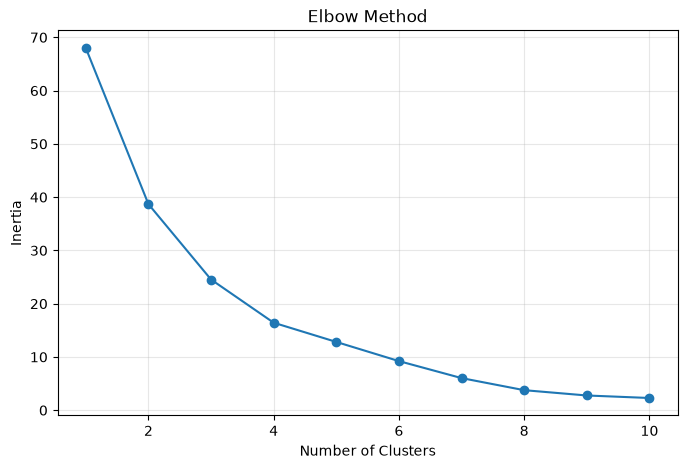

In [386]:
inertia = []

for k in range(1, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    inertia.append(model.inertia_)


plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.grid(alpha=0.3)

plt.savefig("charts/elbow_method.png",)
plt.show()






## 4. Label each cluster meaningfully, for example:
### 1. High Volume, Stable Demand
### 2. Low Volume, High Volatility
### 3. Growing Demand
### 4. Declining Demand


In [387]:
cluster_labels = {
    0: "High Volume, Stable Demand",
    1: "Declining Demand",
    2: "Growing Demand",
    3: "Low Volume, High Volatility"
}

product_features["Cluster Label"] = (
    product_features["Cluster"].map(cluster_labels)
)
product_features

,Sub-Category,Total Sales Volume,Sales Growth Rate,Sales Volatility,Average Order Value,Cluster,Cluster Label
0,Accessories,164186.7000,0.395482,2579.994809,217.178175,3,"Low Volume, High Volatility"
1,Appliances,104618.4030,0.545645,1821.621539,227.926804,0,"High Volume, Stable Demand"
2,Art,26705.4100,0.498255,330.488343,34.019631,0,"High Volume, Stable Demand"
3,Binders,200028.7850,0.463863,3848.223648,134.067550,3,"Low Volume, High Volatility"
4,Bookcases,113813.1987,0.142674,2220.405080,503.598224,1,Declining Demand
5,Chairs,322822.7310,0.137445,4407.232960,531.833165,3,"Low Volume, High Volatility"
6,Copiers,146248.0940,0.357947,5500.774391,2215.880212,2,Growing Demand
7,Envelopes,16128.0460,-0.241905,228.218688,65.032444,1,Declining Demand
8,Fasteners,3001.9600,-0.096378,48.742229,14.027850,1,Declining Demand
9,Furnishings,89212.0180,0.050645,1360.017867,95.823865,1,Declining Demand


## 5. Plot clusters using a 2D scatter plot (use PCA to reduce to 2 dimensions if needed)


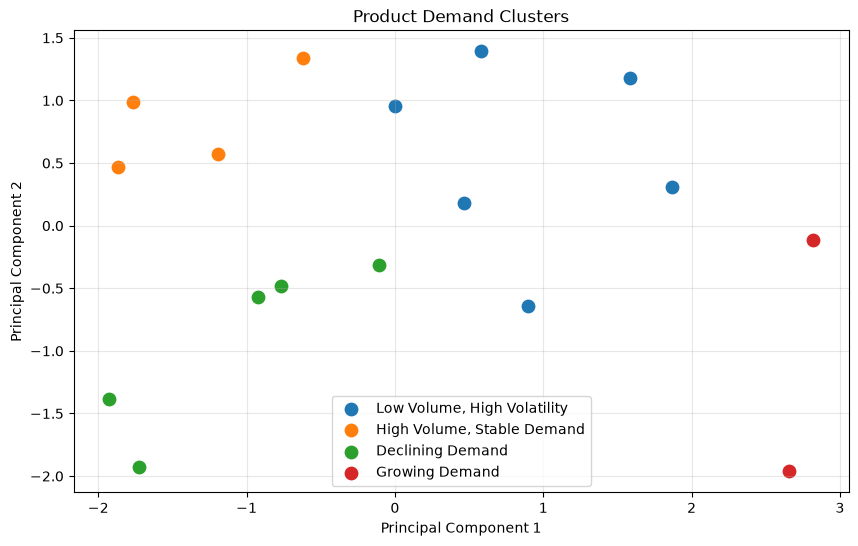

In [388]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(
    scaled_features
)

product_features["PC1"] = pca_features[:,0]

product_features["PC2"] = pca_features[:,1]

product_features


plt.figure(figsize=(10,6))

for cluster in product_features["Cluster"].unique():

    subset = product_features[
        product_features["Cluster"] == cluster
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=80,
        label=cluster_labels[cluster]
    )

plt.title("Product Demand Clusters")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.legend()

plt.grid(alpha=0.3)

plt.savefig("charts/product_demand_clusters.png",)

plt.show()

## for page 4 of the dashboard, we will save the product_features dataframe to a CSV file for further analysis and visualization in the Streamlit app.
product_features.to_csv(
    "models/product_clusters.csv",
    index=True
)

## 6. Write: what stocking strategy would you recommend for each cluster?


## Recommended Stocking Strategy

### High Volume, Stable Demand
Maintain high inventory levels because demand is consistent and predictable.

### Growing Demand
Gradually increase inventory to meet the expected rise in customer demand.

### Low Volume, High Volatility
Maintain limited stock and replenish inventory based on actual demand to reduce holding costs.

### Declining Demand
Avoid overstocking and maintain only essential inventory while monitoring future demand trends.

# Task 7 — Deployment: Interactive Dashboard using Streamlit
 ## Build a working Streamlit web app with the following features:
 ## Page 1 — Sales Overview Dashboard
 1. Total sales by year (bar chart)
 2. Monthly sales trend line chart
 3. Sales by region and category (interactive filters)
 ## Page 2 — Forecast Explorer
 1. Dropdown to select: Category or Region
 2. Date range slider to select forecast horizon (1, 2, or 3 months ahead)
 3. Display the forecast output from your best model for the selected inputs
 4. Show MAE and RMSE of the model below the chart
 ## Page 3 — Anomaly Report
 1. Display the anomaly chart from Task 5
 2. List detected anomaly dates in a table with their sales values
## Page 4 — Product Demand Segments
1. Display the cluster chart from Task 6
2. Show which sub-categories belong to which demand cluster in a table
## Deploy the app on Streamlit Community Cloud (free) and submit the live link.


In [389]:
import streamlit as st

st.set_page_config(
    page_title="Sales Forecasting & Demand Intelligence",
    page_icon="📈",
    layout="wide"
)

st.title("Sales Forecasting & Demand Intelligence System")

st.markdown(
    """
Welcome to the interactive dashboard for the **Sales Forecasting & Demand Intelligence System**.

Use the navigation panel on the left to explore:

- Sales Overview Dashboard
- Forecast Explorer
- Anomaly Report
- Product Demand Segments
"""
)

st.info(
    "This dashboard was developed as part of the XYLOFY AI Machine Learning Internship Project."
)

2026-07-13 15:34:44.505 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 15:34:44.506 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 15:34:44.506 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 15:34:44.507 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 15:34:44.507 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 15:34:44.507 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 15:34:44.508 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 15:34:44.508 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()